In [77]:
using OrdinaryDiffEq, CairoMakie
using Random
using Optim
using ForwardDiff
using ADTypes: AutoForwardDiff
using StableRNGs, QuasiMonteCarlo
using Statistics: mean
using ProgressMeter

# UDE Specific
using Lux
using ComponentArrays: ComponentArray
using DataInterpolations

# Universal Differential Equations
In the final part of this workshop, we'll focus on universal differential equations. As opposed to PINNs, we're now directly trying to learn a part of the equations, instead of learning the *solution* to the equations. Instead of finding the solution with a neural network, we're now just using conventional ODE solvers, and learning a part of the equation with a neural network.

Given an ODE

$$ \frac{\mathrm{d}x}{\mathrm{d}t} = f(x,t) $$

With observable mapping:
$$ y = g(x) $$

*(If we can measure $x(t)$ directly, we'll have $g(x) = x$)*

We can distinguish three variations of correcting our model for our measured data $y$:

### I: Output correction
$$ y = g(x) + \text{NN}_{\theta}(\cdot) $$

### II: Dynamics correction
$$ \frac{\mathrm{d}x}{\mathrm{d}t} = f(x,t) + \text{NN}_{\theta}(\cdot)$$

### III: Parameter correction
$$ p = p_{ODE} + \text{NN}_{\theta}(\cdot)$$

We've seen the output correction in the _Hybrid modelling in series_ tutorial already. In this part, we'll generally focus on type II, dynamics correction. 


## Problem Setup
In this part, we'll look at a simple ODE model of an enzymatic reaction, just like in the previous part.

In [78]:
function enzyme_reaction_inh!(du, u, p, t)
    k1, kn1, k2, k3, kn3 = p
    S, E, ES, P, I, EI = u

    du[1] = -k1 * S * E + kn1 * ES
    du[2] = -k1 * S * E + (kn1 + k2) * ES + kn3 * EI - k3 * E * I
    du[3] = k1 * S * E - (kn1 + k2) * ES
    du[4] = k2 * ES
    du[5] = -k3 * E * I + kn3 * EI
    du[6] = k3 * E * I - kn3 * EI
end

p = [0.7, 0.5, 0.1, 0.2, 0.3]  # parameters: k1, kn1, k2, k3, kn3
u0 = [1.0, 0.08, 0.0, 0.0, 0.0, 0.0]  # initial conditions

tspan = (0.0, 20.0)
prob = ODEProblem(enzyme_reaction_inh!, u0, tspan, p)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
Non-trivial mass matrix: false
timespan: (0.0, 20.0)
u0: 6-element Vector{Float64}:
 1.0
 0.08
 0.0
 0.0
 0.0
 0.0

To generate data, we'll do three experiments.

1. No inhibitor present
2. Initial concentration of 1 mmol/L inhibitor
3. Initial concentration of 4 mmol/L inhibitor

We'll measure our substrate and product every 2 minutes

In [79]:
experiment_1 = solve(prob, Tsit5(), saveat=2.0, save_idxs=[1, 4, 5])
experiment_2 = solve(prob, Tsit5(), saveat=2.0, save_idxs=[1, 4, 5], u0 = [1.0, 0.08, 0.0, 0.0, 1.0, 0.0])
experiment_3 = solve(prob, Tsit5(), saveat=2.0, save_idxs=[1, 4, 5], u0 = [1.0, 0.08, 0.0, 0.0, 4.0, 0.0]);

Let's visualize the three experiments

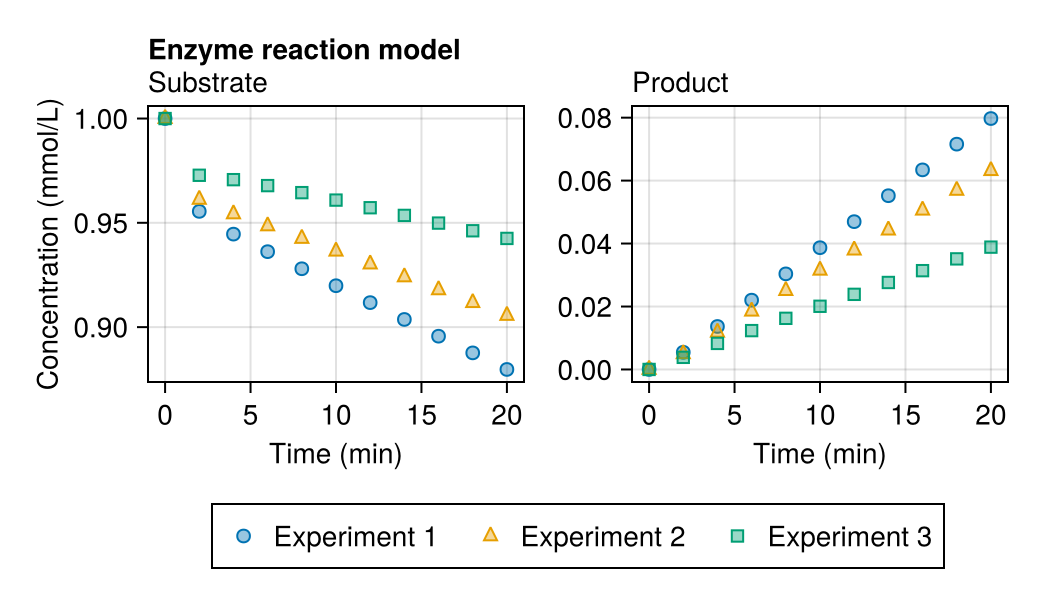

In [80]:
f,ax,l = scatter(experiment_1, idxs=1, strokecolor=Makie.wong_colors()[1], strokewidth=1, alpha=0.4, label="Experiment 1", figure=(size = (520,300),),axis=(
  title="Enzyme reaction model", xlabel="Time (min)", ylabel = "Concentration (mmol/L)",subtitle="Substrate", titlealign=:left)
)
scatter(f[1,2],experiment_1,idxs=2, strokecolor=Makie.wong_colors()[1], strokewidth=1, alpha=0.4, axis=(subtitle="Product", titlealign=:left, xlabel="Time (min)"))

for (exp, cid, marker) in zip([experiment_2, experiment_3], [2, 3], [:utriangle, :rect])
    scatter!(f[1,1],exp,idxs=1, strokecolor=Makie.wong_colors()[cid], strokewidth=1, alpha=0.4, marker=marker, label="Experiment $cid")
    scatter!(f[1,2],exp,idxs=2, strokecolor=Makie.wong_colors()[cid], strokewidth=1, alpha=0.4, marker=marker, label="Experiment $cid")

end

Legend(f[2,1:2], ax, orientation=:horizontal)

f

### The part we know
Imagine we only know the enzymatic reaction without the inhibitor.

We can implement this and try to estimate the parameters for our experiments:

In [81]:
function known_ode!(du, u, p, t)
    S, P, E, ES = u
    k1, kn1, k2 = p
    du[1] = -k1 * S * E + kn1 * (ES)  # dS/dt
    du[2] = k2 * (ES)  # dP/dt
    du[3] = -k1 * S * E + (kn1 + k2) * (ES)  # dE/dt
    du[4] = k1 * S * E - (kn1 + k2) * (ES)  # dES/dt
    
end

u0_known = [1.0, 0.0, 0.08, 0.0]

function sum_of_squares(p, (prob, experiment_1, experiment_2, experiment_3, timepoints))
    sol = Array(solve(prob, Tsit5(), saveat=timepoints, p=exp.(p)))
    loss_S = sum(sum(abs2, sol[1, :] - exp[1, :]) for exp in [experiment_1, experiment_2, experiment_3])
    loss_P = sum(sum(abs2, sol[2, :] - exp[2, :]) for exp in [experiment_1, experiment_2, experiment_3])
    return loss_S + loss_P
end

prob_known = ODEProblem(known_ode!, u0_known, tspan, [1.0, 1.0, 1.0])

lossf = TwiceDifferentiable(
  parameters -> sum_of_squares(parameters, (prob_known, experiment_1, experiment_2, experiment_3, 0:2:20)),
  ones(3);
  autodiff = AutoForwardDiff()
)

lower_bound = ones(3) .* -10.0
upper_bound = ones(3) .* 1.5
constraints = TwiceDifferentiableConstraints(lower_bound, upper_bound)
opt_solution = optimize(lossf, constraints, ones(3), IPNewton())

 * Status: success

 * Candidate solution
    Final objective value:     1.309980e-02

 * Found with
    Algorithm:     Interior Point Newton

 * Convergence measures
    |x - x'|               = 1.88e-04 ≰ 0.0e+00
    |x - x'|/|x'|          = 8.14e-05 ≰ 0.0e+00
    |f(x) - f(x')|         = 6.71e-12 ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 5.12e-10 ≰ 0.0e+00
    |g(x)|                 = 3.56e-09 ≤ 1.0e-08

 * Work counters
    Seconds run:   2  (vs limit Inf)
    Iterations:    29
    f(x) calls:    35
    ∇f(x) calls:   35
    ∇f(x)ᵀv calls: 0
    ∇²f(x) calls:  30
    ∇²f(x)v calls: 0


Let's see how we did

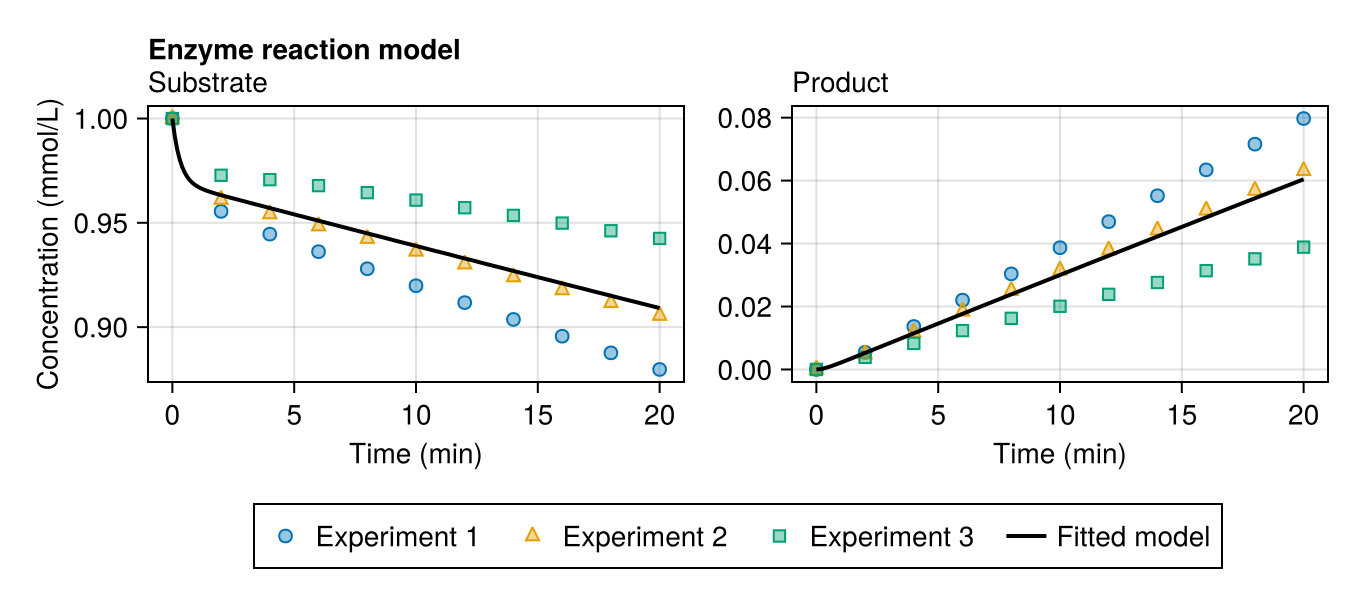

In [82]:
sol_opt = solve(prob_known, Tsit5(), saveat=0:0.1:20, p=exp.(opt_solution.minimizer))

f,ax,l = scatter(experiment_1, idxs=1, strokecolor=Makie.wong_colors()[1], strokewidth=1, alpha=0.4, label="Experiment 1", figure=(size = (680,300),),axis=(
  title="Enzyme reaction model", xlabel="Time (min)", ylabel = "Concentration (mmol/L)",subtitle="Substrate", titlealign=:left)
)
scatter(f[1,2],experiment_1,idxs=2, strokecolor=Makie.wong_colors()[1], strokewidth=1, alpha=0.4, axis=(subtitle="Product", titlealign=:left, xlabel="Time (min)"))

for (exp, cid, marker) in zip([experiment_2, experiment_3], [2, 3], [:utriangle, :rect])
    scatter!(f[1,1],exp,idxs=1, strokecolor=Makie.wong_colors()[cid], strokewidth=1, alpha=0.4, marker=marker, label="Experiment $cid")
    scatter!(f[1,2],exp,idxs=2, strokecolor=Makie.wong_colors()[cid], strokewidth=1, alpha=0.4, marker=marker, label="Experiment $cid")

end
lines!(f[1,1], 0:0.1:20, sol_opt[1, :], color=:black, linewidth=2, label="Fitted model")
lines!(f[1,2], 0:0.1:20, sol_opt[2, :], color=:black, linewidth=2, label="Fitted model")
Legend(f[2,1:2], ax, orientation=:horizontal)

f

We see that our model finds some middle ground between the different experiments. We now want to learn our inhibitor effects. As we have not measured our inhibitor, we only know what we've added. Therefore, as a forcing function, we'll supply the inhibitor concentrations we added and assume they are not consumed by the system at all.

In [83]:
force_exp_1(t) = 0.0
force_exp_2(t) = 1.0
force_exp_3(t) = 4.0;

To build our UDE, we need to determine where to put the neural network. We can either influence the binding of subtrate to enzyme, or the conversion of complex to product. Let's define both and see which one works better.

### Proposition 1: Neural network on the conversion of complex to product
$$ \frac{\mathrm{d}P}{\mathrm{d}t} = k_2 ES \cdot \text{NN}_{\theta}(ES, I) $$
$$ \frac{\mathrm{d}ES}{\mathrm{d}t} = k_1 S E - (k_{-1} + k_2 \cdot \text{NN}_{\theta}(ES, I)) ES $$

### Proposition 2: Neural network on the binding of substrate to enzyme
$$ \frac{\mathrm{d}S}{\mathrm{d}t} = -k_1 S E \cdot \text{NN}_{\theta}(E, I) + k_{-1} ES $$
$$ \frac{\mathrm{d}E}{\mathrm{d}t} = -k_1 S E \cdot \text{NN}_{\theta}(E, I) + (k_{-1} + k_2) ES $$
$$ \frac{\mathrm{d}ES}{\mathrm{d}t} = k_1 S E \cdot \text{NN}_{\theta}(E, I) - (k_{-1} + k_2) ES $$

Below, we'll start with proposition 1 and see how well it performs. Later, you can try proposition 2 and see if it performs better.

In [84]:
function proposition_1!(du, u, p, t, network, force)
    S, P, E, ES = u
    k1, kn1, k2 = p.known

    correction = network([ES, force(t)], p.network)

    du[1] = -k1 * S * E + kn1 * (ES)  # dS/dt
    du[2] = k2 * (ES) * correction  # dP/dt
    du[3] = -k1 * S * E + (kn1 + k2 * correction) * (ES) # dE/dt
    du[4] = k1 * S * E - (kn1+ k2 * correction) * (ES) # dES/dt
end

proposition_1! (generic function with 1 method)

Define the neural network:

In [85]:
softplus(x) = log(1 + exp(x))
rng = StableRNG(1234)

# we initialize weights close to zero to avoid large corrections at the beginning of training
function build_weight_initializer(;scale=1e-3)
    return (rng, out_dims, in_dims) -> scale * randn(rng, out_dims, in_dims)
end

chain = Chain(
    Dense(2, 4, softplus, use_bias=false, init_weight=build_weight_initializer()),
    Dense(4, 1, softplus, use_bias=false, init_weight=build_weight_initializer())
)

p_init, st = Lux.setup(rng, chain)

function network(u, p)
    return chain(u, p, st)[1][1]
end

network([1.0, 0.0], p_init)  # test the network with some input

0.6922567871850771

We will fit the UDE with the sum of squared errors over all three experiments. We will also define a function to set up the optimization problem for us, so we can easily switch between proposition 1 and proposition 2 later.

In [86]:
u0_known = [1.0, 0.0, 0.08, 0.0]

function sum_of_squares_ude(p, (prob_1, prob_2, prob_3, experiment_1, experiment_2, experiment_3, timepoints, u0))
    loss = eltype(p.known)(0.0)
    params = ComponentArray(
        known = exp.(p.known),
        network = p.network
    )
    for (exp, prob) in zip([experiment_1, experiment_2, experiment_3], [prob_1, prob_2, prob_3])
        sol = Array(solve(prob, Rodas5P(), saveat=timepoints, p=params, u0=eltype(p.known).(u0)))
        if size(sol, 2) != length(timepoints)
            return eltype(p.known)(Inf)
        end
        loss_S = sum(sum(abs2, sol[1, :] - exp[1, :]))
        loss_P = sum(sum(abs2, sol[2, :] - exp[2, :]))
        loss += loss_S + loss_P
    end
    return loss
end

function get_optimization_setup(proposition!, force_1, force_2, force_3)
    prob_1 = ODEProblem((du, u, p, t) -> proposition!(du, u, p, t, network, force_1), u0_known, tspan, ComponentArray(known=exp.(ones(2)), network=p_init))
    prob_2 = ODEProblem((du, u, p, t) -> proposition!(du, u, p, t, network, force_2), u0_known, tspan, ComponentArray(known=exp.(ones(2)), network=p_init))
    prob_3 = ODEProblem((du, u, p, t) -> proposition!(du, u, p, t, network, force_3), u0_known, tspan, ComponentArray(known=exp.(ones(2)), network=p_init))

    lossf = TwiceDifferentiable(
        parameters -> sum_of_squares_ude(parameters, (prob_1, prob_2, prob_3, experiment_1, experiment_2, experiment_3, 0:2:20, u0_known)),
        ComponentArray(known=exp.(ones(3)), network=p_init);
        autodiff = AutoForwardDiff()
    )

    return lossf
end

get_optimization_setup (generic function with 1 method)

We can test the loss function by evaluating it with the initial parameters. We should see a high loss, as our model is not yet trained.

In [87]:

prob_1 = ODEProblem((du, u, p, t) -> proposition_1!(du, u, p, t, network, force_exp_1), u0_known, tspan, ComponentArray(known=exp.(ones(3)), network=p_init))
prob_2 = ODEProblem((du, u, p, t) -> proposition_1!(du, u, p, t, network, force_exp_2), u0_known, tspan, ComponentArray(known=exp.(ones(3)), network=p_init))
prob_3 = ODEProblem((du, u, p, t) -> proposition_1!(du, u, p, t, network, force_exp_3), u0_known, tspan, ComponentArray(known=exp.(ones(3)), network=p_init))
sum_of_squares_ude(ComponentArray(known=exp.(ones(3)), network=p_init), (prob_1, prob_2, prob_3, experiment_1, experiment_2, experiment_3, 0:2:20, u0_known))

46.00228354369122

Let's define the optimization problem and train our model.

In [96]:
loss_ude_1 = get_optimization_setup(proposition_1!, force_exp_1, force_exp_2, force_exp_3);

For this problem, we will use a two-stage optimization approach. First, we will optimize the system with ADAM for a few iterations. Then, we will use the optimized parameters as a starting point for a BFGS optimization. 

For UDEs, this is typically a fine approach, as the ADAM optimization will get us close to a good solution, and the BFGS optimization will refine it further. Some alternative optimization methods for UDEs have been proposed and have shown to work better, but for this workshop, we will stick to the ADAM + BFGS approach.

In [89]:
function get_progress_callback(n_iter)
    prog = Progress(n_iter, "Optimizing UDE parameters")
    return (state) -> begin
        next!(prog)
        false
    end
end

# run ADAM for 200 iterations
println("Running ADAM optimization...")
res_1 = optimize(
    loss_ude_1,
    ComponentArray(known=exp.(ones(3)), network=p_init),
    Adam(;alpha=0.01),
    Optim.Options(iterations=1000,callback=get_progress_callback(1000))
)
println("ADAM optimization finished. Loss: $(res_1.minimum)")
res_1 = optimize(
    loss_ude_1,
    res_1.minimizer,
    LBFGS(),
    Optim.Options(iterations=1000,callback=get_progress_callback(1000))
)
println("BFGS optimization finished. Loss: $(res_1.minimum)")
res_1


    

Running ADAM optimization...


Optimizing UDE parameters 100%|██████████████████████████| Time: 0:00:12


ADAM optimization finished. Loss: 0.02461819404223883


Optimizing UDE parameters  14%|███▋                      |  ETA: 0:00:30

BFGS optimization finished. Loss: 0.0013825068817563198


 * Status: success

 * Candidate solution
    Final objective value:     1.382507e-03

 * Found with
    Algorithm:     L-BFGS

 * Convergence measures
    |x - x'|               = 0.00e+00 ≤ 0.0e+00
    |x - x'|/|x'|          = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|         = 0.00e+00 ≤ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 0.00e+00 ≤ 0.0e+00
    |g(x)|                 = 2.67e-05 ≰ 1.0e-08

 * Work counters
    Seconds run:   5  (vs limit Inf)
    Iterations:    137
    f(x) calls:    1743
    ∇f(x) calls:   1743
    ∇f(x)ᵀv calls: 0


Great, we've found a solution that seems to fit our data well. Let's visualize the results and see how well our model performs.

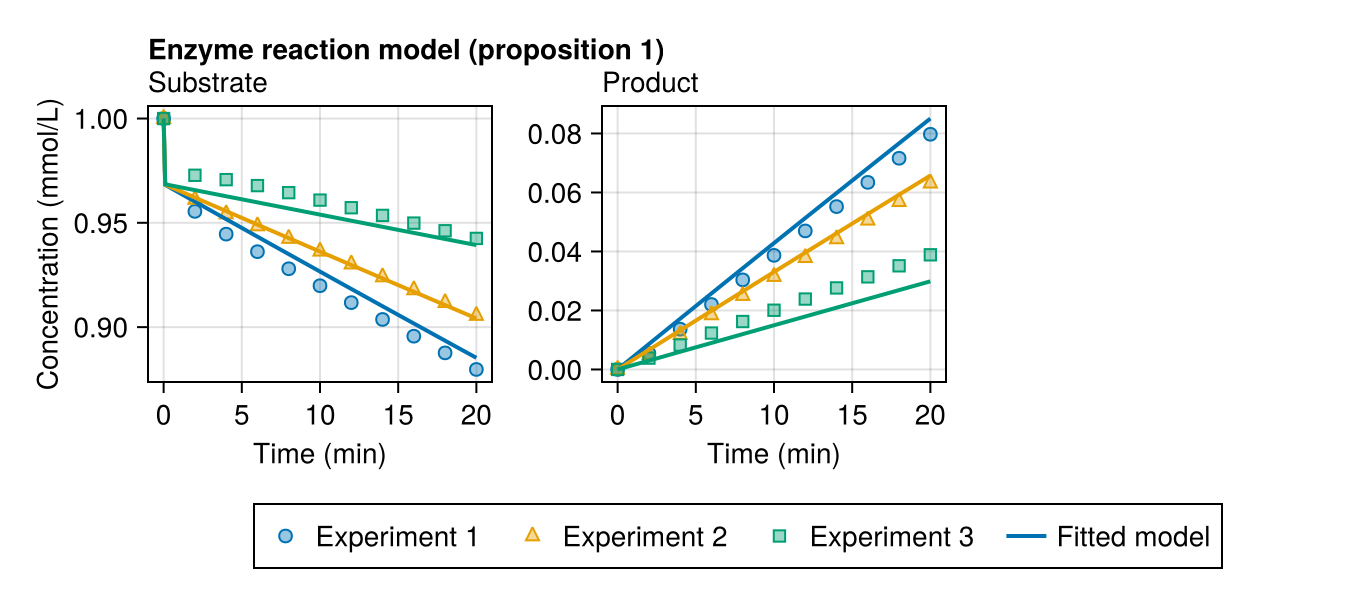

In [90]:
opt_params = ComponentArray(known=exp.(res_1.minimizer.known), network=res_1.minimizer.network)

prob_1 = ODEProblem((du, u, p, t) -> proposition_1!(du, u, p, t, network, force_exp_1), u0_known, tspan, ComponentArray(known=exp.(ones(3)), network=p_init))
prob_2 = ODEProblem((du, u, p, t) -> proposition_1!(du, u, p, t, network, force_exp_2), u0_known, tspan, ComponentArray(known=exp.(ones(3)), network=p_init))
prob_3 = ODEProblem((du, u, p, t) -> proposition_1!(du, u, p, t, network, force_exp_3), u0_known, tspan, ComponentArray(known=exp.(ones(3)), network=p_init))

sol_opt_1 = solve(prob_1, Rodas5P(), saveat=0:0.1:20, p=opt_params)
sol_opt_2 = solve(prob_2, Rodas5P(), saveat=0:0.1:20, p=opt_params)
sol_opt_3 = solve(prob_3, Rodas5P(), saveat=0:0.1:20, p=opt_params)

f,ax,l = scatter(experiment_1, idxs=1, strokecolor=Makie.wong_colors()[1], strokewidth=1, alpha=0.4, label="Experiment 1", figure=(size = (680,300),),axis=(
  title="Enzyme reaction model (proposition 1)", xlabel="Time (min)", ylabel = "Concentration (mmol/L)",subtitle="Substrate", titlealign=:left)
)
scatter(f[1,2],experiment_1,idxs=2, strokecolor=Makie.wong_colors()[1], strokewidth=1, alpha=0.4, axis=(subtitle="Product", titlealign=:left, xlabel="Time (min)"))

for (exp, cid, marker) in zip([experiment_2, experiment_3], [2, 3], [:utriangle, :rect])
    scatter!(f[1,1],exp,idxs=1, strokecolor=Makie.wong_colors()[cid], strokewidth=1, alpha=0.4, marker=marker, label="Experiment $cid")
    scatter!(f[1,2],exp,idxs=2, strokecolor=Makie.wong_colors()[cid], strokewidth=1, alpha=0.4, marker=marker, label="Experiment $cid")

end
lines!(f[1,1], 0:0.1:20, sol_opt_1[1, :], color=Makie.wong_colors()[1], linewidth=2, label="Fitted model")
lines!(f[1,2], 0:0.1:20, sol_opt_1[2, :], color=Makie.wong_colors()[1], linewidth=2)

lines!(f[1,1], 0:0.1:20, sol_opt_2[1, :], color=Makie.wong_colors()[2], linewidth=2)
lines!(f[1,2], 0:0.1:20, sol_opt_2[2, :], color=Makie.wong_colors()[2], linewidth=2)

lines!(f[1,1], 0:0.1:20, sol_opt_3[1, :], color=Makie.wong_colors()[3], linewidth=2)
lines!(f[1,2], 0:0.1:20, sol_opt_3[2, :], color=Makie.wong_colors()[3], linewidth=2)

Legend(f[2,1:3], ax, orientation=:horizontal)

f

We can see that the model at least captures some differences between the experiments, but it is not perfect. We can try to improve the model by using proposition 2 instead of proposition 1. You can try this yourself and see if it performs better.

### DIY
**DIY 1)** Implement the UDE with proposition 2 and see if it performs better than proposition 1.

In [ ]:
# DIY 1 code here

### Analysing the Neural network
After training, we can analyze the neural network to see what it has learned. We can visualize the neural network output as a function of the inputs. This can give us some insight into how the inhibitor affects the enzymatic reaction.

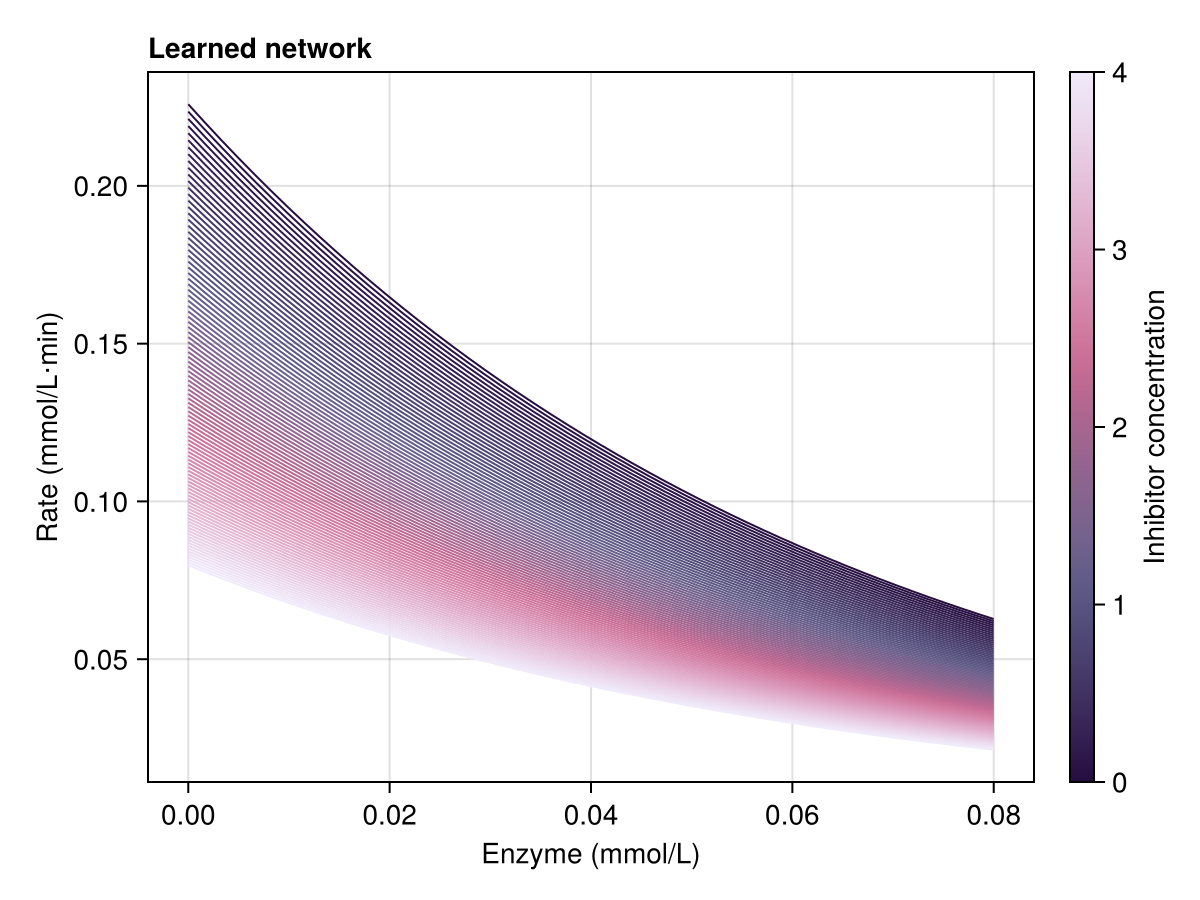

In [94]:
I_vals = range(0.0, stop=4.0, length=100)
ES_vals = range(0.0, stop=0.08, length=50)

net_params = res_1.minimizer.network
k2 = exp.(res_1.minimizer.known)[3]
network([0.0, 0.0,], net_params)  # test the network with some input

figure_network = let f = Figure()
    ax = Axis(f[1,1], title="Learned network", xlabel="Enzyme (mmol/L)", ylabel = "Rate (mmol/L⋅min)", titlealign=:left)
    Z = [network([E, I], net_params)*k2 for E in E_vals, I in I_vals]
    cmap = get(Makie.ColorSchemes.acton, range(0.0, 1.0, length=length(I_vals)))
    for i in 1:length(I_vals)
        color = cmap[i]
        lines!(ax, E_vals, Z[:, i], color=color, label="I=$(round(I_vals[i], digits=2))", linewidth=1.0)
    end
    Colorbar(f[1,2], colormap=Makie.ColorSchemes.acton, limits=(0.0, 4.0), label="Inhibitor concentration")

    f
end

## Extrapolation to new inhibitor concentrations
Let's see how our model performs on new inhibitor concentrations. We'll do two new experiments, one with 2 mmol/L inhibitor and one with 8 mmol/L inhibitor. We'll see how well our model can predict the outcome of these experiments.

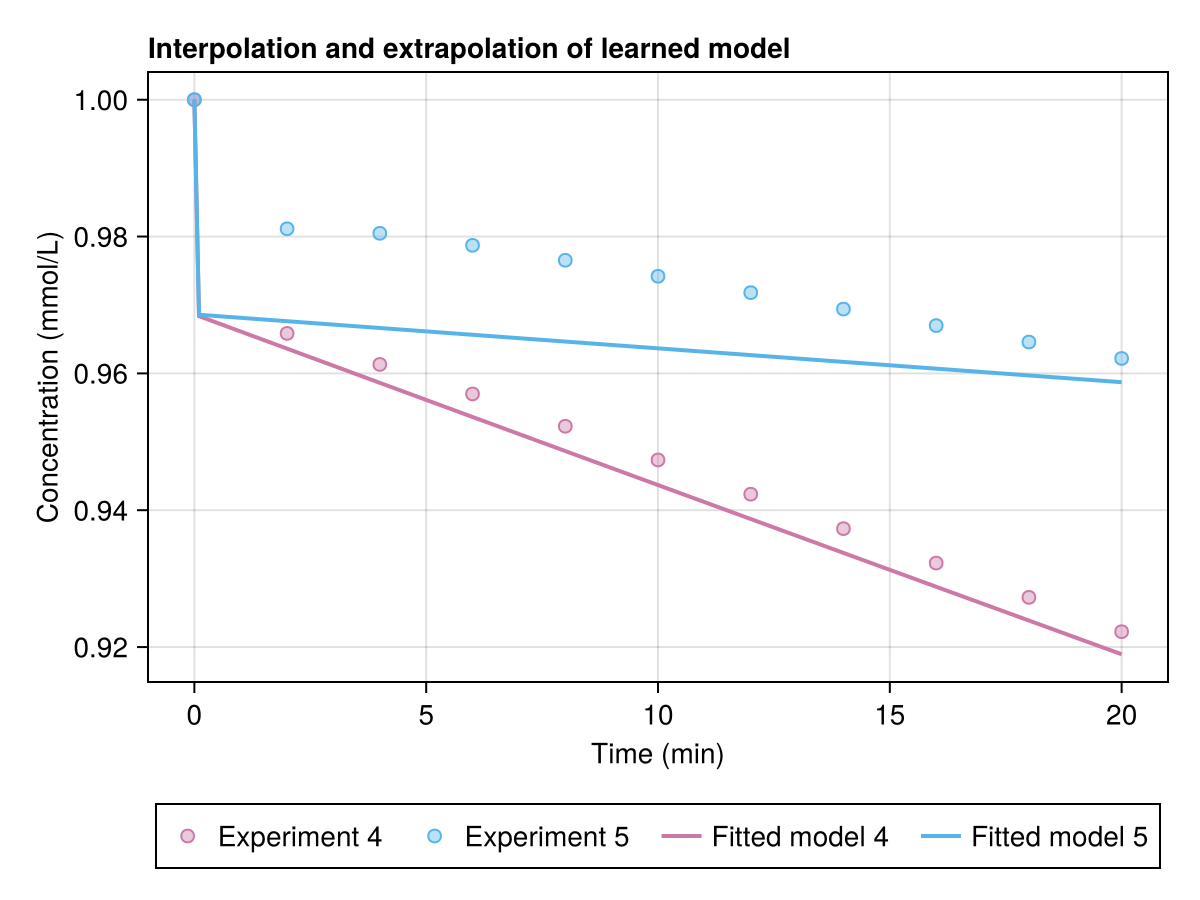

In [95]:
experiment_4 = solve(prob, Tsit5(), saveat=2.0, save_idxs=[1, 4, 5], u0 = [1.0, 0.08, 0.0, 0.0, 2.0, 0.0])
experiment_5 = solve(prob, Tsit5(), saveat=2.0, save_idxs=[1, 4, 5], u0 = [1.0, 0.08, 0.0, 0.0, 8.0, 0.0])

force_exp_4(t) = 2.0
force_exp_5(t) = 8.0

prob_4 = ODEProblem((du, u, p, t) -> proposition_1!(du, u, p, t, network, force_exp_4), u0_known, tspan, ComponentArray(known=exp.(ones(2)), network=p_init))
prob_5 = ODEProblem((du, u, p, t) -> proposition_1!(du, u, p, t, network, force_exp_5), u0_known, tspan, ComponentArray(known=exp.(ones(2)), network=p_init))

opt_params = ComponentArray(known=exp.(res_1.minimizer.known), network=res_1.minimizer.network)

sol_opt_4 = solve(prob_4, Rodas5P(), saveat=0:0.1:20, p=opt_params)
sol_opt_5 = solve(prob_5, Rodas5P(), saveat=0:0.1:20, p=opt_params)

figure_extrapolation = let f = Figure()
    ax = Axis(f[1,1], title="Interpolation and extrapolation of learned model", xlabel="Time (min)", ylabel = "Concentration (mmol/L)", titlealign=:left)
    scatter!(ax, experiment_4, idxs=1, strokecolor=Makie.wong_colors()[4], strokewidth=1, alpha=0.4, label="Experiment 4", color=Makie.wong_colors()[4])
    scatter!(ax, experiment_5, idxs=1, strokecolor=Makie.wong_colors()[5], strokewidth=1, alpha=0.4, label="Experiment 5", color=Makie.wong_colors()[5])
    lines!(ax, 0:0.1:20, sol_opt_4[1, :], color=Makie.wong_colors()[4], linewidth=2, label="Fitted model 4")
    lines!(ax, 0:0.1:20, sol_opt_5[1, :], color=Makie.wong_colors()[5], linewidth=2, label="Fitted model 5")
    Legend(f[2,1], ax, orientation=:horizontal)
    f
end


## DIY
**DIY 2)** Analyse the interpolation and extrapolation capabilities of the UDE model in proposition 2. How does it differ from proposition 1? Are there still areas where the model performs poorly? Can you think of ways to improve the model further?

In [ ]:
# DIY 2 code here